# RBF Isopleth Surface Builder

This notebook demonstrates how to transform isopleth monitoring data into a smooth surface using `scipy.interpolate.Rbf`. Update the configuration cell to target different datasets or interpolation behaviors, then re-run the processing and plotting cells to evaluate the results.

## How To Use
1. Adjust the `CONFIG` dictionary to point at the dataset and tweak interpolation/plotting parameters.
2. Run the *Load & Prepare Data* cell to pull a clean set of latitude/longitude/value triples.
3. Execute the *Interpolate With RBF* cell to build a surface grid.
4. Render the *2D Contour* and *3D Surface* plots to verify the fit against the raw points.

In [3]:
from pathlib import Path

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors
from scipy.interpolate import RBFInterpolator

plt.style.use('seaborn-v0_8-whitegrid')

In [42]:
CONFIG = {
    # Path to the CSV containing isopleth data. Update as needed.
    'data_path': Path('/Users/isaacsudweeks/Desktop/Work/Improved_Isopleths/data/utah/filtered_by_clearing_index/SR_clearing_nonmax_all.csv'),
    # Toggle saving artifacts for the current run.
    'save': True,
    # Directory where plots and params.csv will be written when save=True.
    'output_dir': Path('/Users/isaacsudweeks/Desktop/Work/Improved_Isopleths/plots/utah/SR_filtered/Clearing_Index_Filtered/No_Max/RBF'),
    # Column names in the CSV that hold latitude, longitude, and the value to interpolate.
    'lat_col': 'NOx',
    'lon_col': 'VOC',
    'value_col': 'Ozone',
    # Optional filters applied before interpolation, e.g. {'parameter': ['Carbon disulfide']}.
    'filters': {},
    # Number of grid steps (per axis) when evaluating the surface. Higher = smoother but slower.
    'grid_resolution': 75,
    # Parameters forwarded directly to scipy.interpolate.RBFInterpolator.
    'rbf': {
        'kernel': 'cubic',
        'epsilon': 0.006082,
        'smoothing': 0.369388,
    },
    # Plot styling options.
    'plot': {
        'cmap': 'viridis',
        'contour_levels': 50,
        'surface_alpha': 0.75,
        'scatter_color': 'k',
        'plotly_colorscale': 'Viridis',
        'point_size': 30,
    },
    'title': 'non-max-alltime_clearing_index_over_500',
}
CONFIG

{'data_path': PosixPath('/Users/isaacsudweeks/Desktop/Work/Improved_Isopleths/data/utah/filtered_by_clearing_index/SR_clearing_nonmax_all.csv'),
 'save': True,
 'output_dir': PosixPath('/Users/isaacsudweeks/Desktop/Work/Improved_Isopleths/plots/utah/SR_filtered/Clearing_Index_Filtered/No_Max/RBF'),
 'lat_col': 'NOx',
 'lon_col': 'VOC',
 'value_col': 'Ozone',
 'filters': {},
 'grid_resolution': 75,
 'rbf': {'kernel': 'cubic', 'epsilon': 0.006082, 'smoothing': 0.369388},
 'plot': {'cmap': 'viridis',
  'contour_levels': 50,
  'surface_alpha': 0.75,
  'scatter_color': 'k',
  'plotly_colorscale': 'Viridis',
  'point_size': 30},
 'title': 'non-max-alltime_clearing_index_over_500'}

In [43]:
# Helper to build an RBFInterpolator instance
def make_rbf_interpolator(lon_array, lat_array, value_array, rbf_kwargs):
    lon_array = np.asarray(lon_array, dtype=float)
    lat_array = np.asarray(lat_array, dtype=float)
    value_array = np.asarray(value_array, dtype=float)

    if lon_array.shape != lat_array.shape:
        raise ValueError('Longitude and latitude arrays must share the same shape.')

    normalized = dict(rbf_kwargs or {})
    if 'function' in normalized and 'kernel' not in normalized:
        normalized['kernel'] = normalized.pop('function')
    if 'smooth' in normalized and 'smoothing' not in normalized:
        normalized['smoothing'] = normalized.pop('smooth')

    sample_points = np.column_stack((lon_array, lat_array))
    return RBFInterpolator(sample_points, value_array, **normalized)

In [44]:
# Load & Prepare Data
data_path = Path(CONFIG['data_path'])
lat_col = CONFIG['lat_col']
lon_col = CONFIG['lon_col']
value_col = CONFIG['value_col']

SAVE_OUTPUTS = bool(CONFIG.get('save', False))
output_dir_config = CONFIG.get('output_dir') or (data_path.parent / 'rbf_outputs')
OUTPUT_DIR = Path(output_dir_config).expanduser()
if not OUTPUT_DIR.is_absolute():
    OUTPUT_DIR = Path.cwd() / OUTPUT_DIR
RUN_ID = pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')
ARTIFACT_PREFIX = f'rbf_surface_{RUN_ID}'

if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(data_path)

for col, allowed in CONFIG['filters'].items():
    if allowed:
        df = df[df[col].isin(allowed)]

needed_cols = [lat_col, lon_col, value_col]
df = df[needed_cols].copy()

for col in needed_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=needed_cols)

if len(df) < 4:
    raise ValueError('Need at least four points for RBF interpolation. Adjust filters or dataset.')

print(f"Loaded {len(df)} usable points from {data_path}")
df.head()

Loaded 704 usable points from /Users/isaacsudweeks/Desktop/Work/Improved_Isopleths/data/utah/filtered_by_clearing_index/SR_clearing_nonmax_all.csv


,NOx,VOC,Ozone
0,2.95,14.1580,73.0
1,2.80,22.4996,71.0
2,2.95,17.8873,61.0
3,4.30,18.3901,65.0
4,4.20,20.1793,64.0


In [45]:
# Interpolate With RBFInterpolator
lon = df[lon_col].to_numpy()
lat = df[lat_col].to_numpy()
values = df[value_col].to_numpy()

grid_res = CONFIG['grid_resolution']
lon_lin = np.linspace(lon.min(), lon.max(), grid_res)
lat_lin = np.linspace(lat.min(), lat.max(), grid_res)
lon_grid, lat_grid = np.meshgrid(lon_lin, lat_lin)

rbf = make_rbf_interpolator(lon, lat, values, CONFIG['rbf'])
grid_points = np.column_stack((lon_grid.ravel(), lat_grid.ravel()))
value_grid = rbf(grid_points).reshape(lon_grid.shape)

value_min = float(np.nanmin(value_grid))
value_max = float(np.nanmax(value_grid))
value_mean = float(np.nanmean(value_grid))

summary = {
    'value_min': value_min,
    'value_max': value_max,
    'value_mean': value_mean,
}

norm = colors.Normalize(vmin=0, vmax=value_max)

params_record = {
    'run_id': RUN_ID,
    'data_path': str(data_path),
    'lat_col': lat_col,
    'lon_col': lon_col,
    'value_col': value_col,
    'grid_resolution': grid_res,
    'filters': json.dumps(CONFIG.get('filters', {})),
    'value_min': value_min,
    'value_max': value_max,
    'value_mean': value_mean,
}
for key, value in CONFIG.get('rbf', {}).items():
    params_record[f'rbf_{key}'] = value
for key, value in CONFIG.get('plot', {}).items():
    params_record[f'plot_{key}'] = value

if SAVE_OUTPUTS:
    params_path = OUTPUT_DIR / f'{ARTIFACT_PREFIX}_params.csv'
    pd.DataFrame([params_record]).to_csv(params_path, index=False)

summary

{'value_min': 51.77877569686778,
 'value_max': 77.42344989830451,
 'value_mean': 71.22480118426152}

In [46]:
# Cross-Validation Fit Check
def evaluate_rbf_kfold(lon_array, lat_array, value_array, rbf_kwargs, k=5, shuffle=True, random_state=42):
    lon_array = np.asarray(lon_array)
    lat_array = np.asarray(lat_array)
    value_array = np.asarray(value_array)
    n_samples = len(value_array)

    if k < 2 or k > n_samples:
        raise ValueError('k must be at least 2 and no larger than the number of samples.')

    indices = np.arange(n_samples)
    if shuffle:
        rng = np.random.default_rng(random_state)
        rng.shuffle(indices)

    folds = np.array_split(indices, k)
    fold_stats = []

    for fold_id, test_idx in enumerate(folds, start=1):
        train_idx = np.setdiff1d(indices, test_idx, assume_unique=True)
        if len(train_idx) < 4:
            raise ValueError('Each training fold needs at least four points. Reduce k or use more data.')

        rbf = make_rbf_interpolator(
            lon_array[train_idx],
            lat_array[train_idx],
            value_array[train_idx],
            rbf_kwargs,
        )
        test_points = np.column_stack((lon_array[test_idx], lat_array[test_idx]))
        preds = rbf(test_points)
        residuals = preds - value_array[test_idx]

        fold_stats.append({
            'fold': fold_id,
            'n_test': int(len(test_idx)),
            'rmse': float(np.sqrt(np.mean(residuals ** 2))),
            'mae': float(np.mean(np.abs(residuals))),
            'bias': float(np.mean(residuals)),
        })

    results = pd.DataFrame(fold_stats)
    summary = {
        'rmse_mean': float(results['rmse'].mean()),
        'mae_mean': float(results['mae'].mean()),
        'bias_mean': float(results['bias'].mean()),
    }
    return results, summary

cv_results, cv_summary = evaluate_rbf_kfold(
    lon, lat, values, CONFIG['rbf'],
    k=5,
    shuffle=True,
    random_state=42,
)

display(cv_results)
cv_summary

,fold,n_test,rmse,mae,bias
0,1,141,8.808905,7.106611,0.568705
1,2,141,9.839065,7.133611,0.610457
2,3,141,9.052494,7.057936,0.013211
3,4,141,8.408443,6.947663,-1.048169
4,5,140,8.893874,6.854238,-0.073475


{'rmse_mean': 9.000556337348453,
 'mae_mean': 7.020011946118447,
 'bias_mean': 0.014145910782466334}

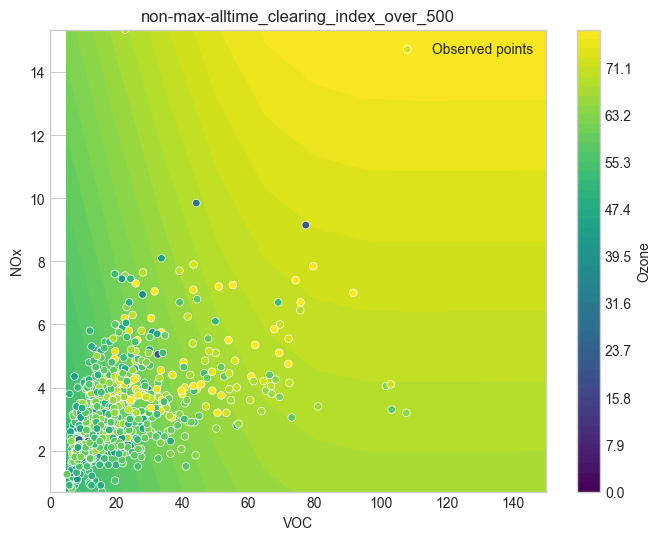

In [47]:
# 2D Contour Plot
plot_cfg = CONFIG['plot']
fig, ax = plt.subplots(figsize=(8, 6))

if 'value_max' not in globals():
    value_max = float(np.nanmax(value_grid))
if 'norm' not in globals():
    norm = colors.Normalize(vmin=0, vmax=value_max)

if isinstance(plot_cfg['contour_levels'], int):
    levels = np.linspace(0, value_max, plot_cfg['contour_levels'])
else:
    levels = plot_cfg['contour_levels']

contour = ax.contourf(lon_grid, lat_grid, value_grid, levels=levels, cmap=plot_cfg['cmap'], norm=norm)
scatter = ax.scatter(lon, lat, c=values, cmap=plot_cfg['cmap'], edgecolor='white', linewidth=0.5, s=plot_cfg['point_size'], norm=norm)

cbar = fig.colorbar(contour, ax=ax, label=value_col)
ax.set_xlim(0,150)
ax.set_xlabel(lon_col)
ax.set_ylabel(lat_col)
ax.set_title(f'{CONFIG["title"]}')
ax.legend([scatter], ['Observed points'], loc='best')

if SAVE_OUTPUTS:
    contour_path = OUTPUT_DIR / f'{ARTIFACT_PREFIX}_2d_contour_{CONFIG['title']}.png'
    fig.savefig(contour_path, dpi=300, bbox_inches='tight')

plt.show()

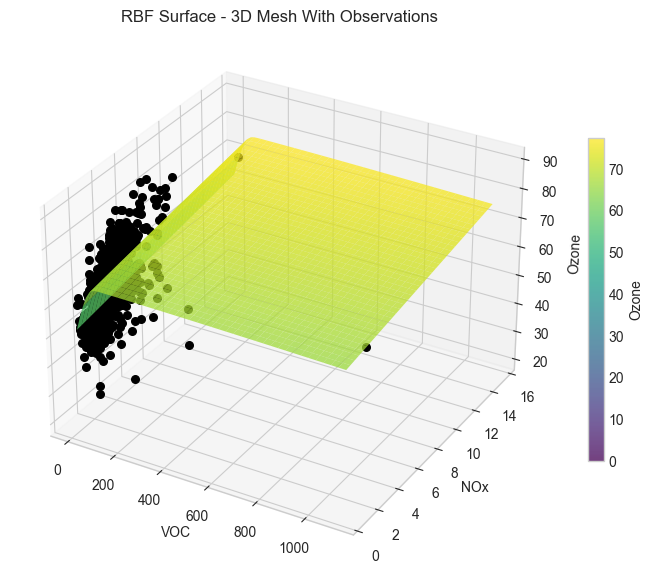

In [48]:
# 3D Surface Plot
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 - imported for side effects

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

if 'norm' not in globals():
    norm = colors.Normalize(vmin=0, vmax=np.nanmax(value_grid))

surface = ax.plot_surface(lon_grid, lat_grid, value_grid, cmap=plot_cfg['cmap'], norm=norm, alpha=plot_cfg['surface_alpha'], linewidth=0, antialiased=True)
ax.scatter(lon, lat, values, color=plot_cfg['scatter_color'], s=plot_cfg['point_size'], depthshade=False)

fig.colorbar(surface, ax=ax, shrink=0.6, label=value_col)
ax.set_xlabel(lon_col)
ax.set_ylabel(lat_col)
ax.set_zlabel(value_col)
ax.set_title('RBF Surface - 3D Mesh With Observations')

if SAVE_OUTPUTS:
    surface_path = OUTPUT_DIR / f'{ARTIFACT_PREFIX}_3d_surface.png'
    fig.savefig(surface_path, dpi=300, bbox_inches='tight')

plt.show()

In [49]:
# Interactive 3D Plot (Plotly)
try:
    import plotly.graph_objects as go
except ImportError as exc:
    raise ImportError('Plotly is required for the interactive 3D view. Install it with `pip install plotly`.') from exc

plotly_scale = CONFIG['plot'].get('plotly_colorscale') or plot_cfg['cmap'].capitalize()
marker_size = max(plot_cfg['point_size'] / 4, 4)
value_max = locals().get('value_max', float(np.nanmax(value_grid)))


fig = go.Figure()
fig.add_surface(
    x=lon_grid,
    y=lat_grid,
    z=value_grid,
    colorscale=plotly_scale,
    opacity=plot_cfg['surface_alpha'],
    cmin=0,
    cmax=value_max,
    showscale=True,
    name='RBF surface',
)
fig.add_scatter3d(
    x=lon,
    y=lat,
    z=values,
    mode='markers',
    marker=dict(
        size=marker_size,
        color=values,
        colorscale=plotly_scale,
        line=dict(width=1, color='white'),
        cmin=0,
        cmax=value_max,
    ),
    name='Observed points',
)
fig.update_layout(
    title='RBF Surface - Interactive 3D',
    scene=dict(
        xaxis_title=lon_col,
        yaxis_title=lat_col,
        zaxis_title=value_col,
    ),
    margin=dict(l=0, r=0, t=40, b=0),
)

if SAVE_OUTPUTS:
    interactive_path = OUTPUT_DIR / f'{ARTIFACT_PREFIX}_interactive.html'
    fig.write_html(interactive_path, include_plotlyjs='cdn')

fig.show()

In [22]:
# Hyperparameter Grid Search (RMSE minimization)
from itertools import product

def _unique_preserve(values):
    seen = set()
    ordered = []
    for item in values:
        if item not in seen:
            ordered.append(item)
            seen.add(item)
    return ordered

default_rbf = CONFIG.get('rbf', {})
# multiquadric
rbf_param_grid = {
    'kernel': _unique_preserve([
        default_rbf.get('kernel', 'thin_plate_spline'),
        'thin_plate_spline',
        'cubic',
        'multiquadric',
        'gaussian',
        'linear',
        'inverse_multiquadric',
        'inverse_quadratic'
    ]),
    'epsilon': _unique_preserve([ i for i in np.linspace(0.001, 0.25,50)
    ]),
    'smoothing': _unique_preserve([ i for i in np.linspace(0.1,1.75,50)]),
}


def grid_search_rbf_params(lon_array, lat_array, value_array, param_grid, **cv_kwargs):
    lon_array = np.asarray(lon_array, dtype=float)
    lat_array = np.asarray(lat_array, dtype=float)
    value_array = np.asarray(value_array, dtype=float)

    param_names = list(param_grid)
    combos = list(product(*param_grid.values()))
    rows = []

    for combo in combos:
        candidate = dict(zip(param_names, combo))
        try:
            _, summary = evaluate_rbf_kfold(
                lon_array,
                lat_array,
                value_array,
                candidate,
                **cv_kwargs,
            )
            rows.append({
                **candidate,
                'rmse_mean': summary['rmse_mean'],
                'mae_mean': summary['mae_mean'],
                'bias_mean': summary['bias_mean'],
                'status': 'ok',
            })
        except Exception as exc:
            rows.append({
                **candidate,
                'rmse_mean': np.inf,
                'mae_mean': np.inf,
                'bias_mean': np.nan,
                'status': f'failed: {exc}',
            })

    results = pd.DataFrame(rows)
    if not results.empty:
        results = results.sort_values(
            'rmse_mean',
            key=lambda values: np.where(np.isfinite(values), values, np.inf),
        ).reset_index(drop=True)
    return results


cv_settings = dict(k=5, shuffle=True, random_state=42)
rbf_search_results = grid_search_rbf_params(lon, lat, values, rbf_param_grid, **cv_settings)
print('Top candidate RBF settings (sorted by mean RMSE):')
display(rbf_search_results.head(10))

finite_mask = np.isfinite(rbf_search_results['rmse_mean']) if not rbf_search_results.empty else []
if np.any(finite_mask):
    best_rbf_params = rbf_search_results.loc[finite_mask].iloc[0].to_dict()
    print('Best RBF parameters based on cross-validated RMSE:')
    best_rbf_params
else:
    best_rbf_params = {}
    print('No successful parameter combinations were found. Inspect rbf_search_results for failure diagnostics.')


Top candidate RBF settings (sorted by mean RMSE):


,kernel,epsilon,smoothing,rmse_mean,mae_mean,bias_mean,status
0,cubic,0.006082,0.369388,9.000556,7.019998,0.014162,ok
1,cubic,0.006082,0.403061,9.002638,7.026349,0.021907,ok
2,cubic,0.006082,0.335714,9.003011,7.027353,0.005920,ok
3,multiquadric,0.011163,0.100000,9.006720,7.061200,-0.004317,ok
4,multiquadric,0.011163,0.133673,9.006760,7.065736,-0.002100,ok
5,multiquadric,0.011163,0.167347,9.007548,7.069254,-0.000306,ok
6,cubic,0.006082,0.436735,9.008521,7.033676,0.029209,ok
7,multiquadric,0.011163,0.201020,9.008680,7.072132,0.001228,ok
8,multiquadric,0.016245,0.268367,9.009136,7.063422,-0.001026,ok
9,multiquadric,0.016245,0.302041,9.009203,7.065342,-0.000285,ok


Best RBF parameters based on cross-validated RMSE:
